In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
pip install ucimlrepo

In [8]:
df = pd.read_csv("Data_Cortex_Nuclear.csv")
df.dropna(inplace=True)

X = df.iloc[:, 1:78].values
y = df["Genotype"].replace({"Control": 0, "Ts65Dn": 1}).values

/tmp/ipython-input-1557195608.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df["Genotype"].replace({"Control": 0, "Ts65Dn": 1}).values


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5, verbose=1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [15]:
model = SVC(kernel='rbf', C=10.0, gamma='scale')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        60

    accuracy                           1.00       111
   macro avg       1.00      1.00      1.00       111
weighted avg       1.00      1.00      1.00       111



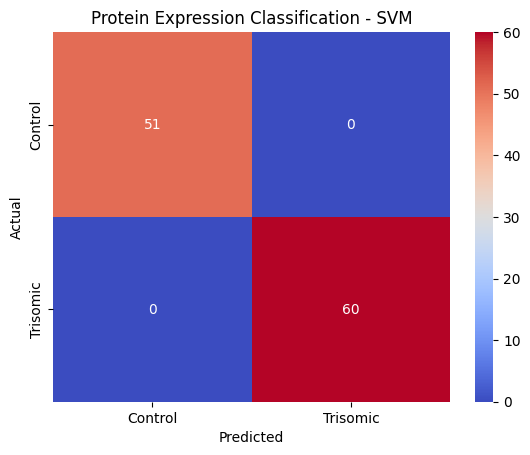

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Control', 'Trisomic'], yticklabels=['Control', 'Trisomic'])
plt.title("Protein Expression Classification - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


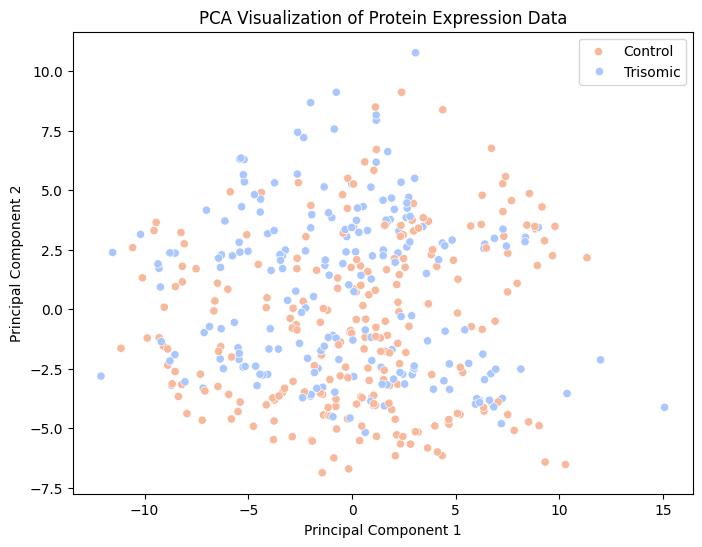

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=y_train, palette='coolwarm')
plt.title("PCA Visualization of Protein Expression Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(["Control", "Trisomic"])
plt.show()
